In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [25]:
df = pd.read_csv("bank.csv", sep=';')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [28]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [31]:
total = len(df)
contacted = total
interested = df[df['duration'] > df['duration'].median()].shape[0]
converted = df[df['y'] == 'yes'].shape[0]
print("📊 MARKETING FUNNEL SUMMARY\n")
print(f"Total Customers     : {total}")
print(f"Contacted Customers : {contacted}")
print(f"Interested Leads    : {interested}")
print(f"Converted Customers : {converted}")

📊 MARKETING FUNNEL SUMMARY

Total Customers     : 45211
Contacted Customers : 45211
Interested Leads    : 22551
Converted Customers : 5289


In [32]:
print("\n📈 CONVERSION RATES\n")
print(f"Contact Rate        : {contacted/total:.2%}")
print(f"Interest Rate       : {interested/contacted:.2%}")
print(f"Conversion Rate     : {converted/interested:.2%}")


📈 CONVERSION RATES

Contact Rate        : 100.00%
Interest Rate       : 49.88%
Conversion Rate     : 23.45%


In [35]:
print("\n 📉 DROP-OFF ANALYSIS\n")
print(f"Drop (Total → Contacted)     : {total - contacted}")
print(f"Drop (Contacted → Interested): {contacted - interested}")
print(f"Drop (Interested → Converted): {interested - converted}")


 📉 DROP-OFF ANALYSIS

Drop (Total → Contacted)     : 0
Drop (Contacted → Interested): 22660
Drop (Interested → Converted): 17262


In [36]:
funnel = pd.DataFrame({
    "Stage": ["Total", "Contacted", "Interested", "Converted"],
    "Users": [
        df['is_customer'].sum(),
        df['is_contacted'].sum(),
        df['is_interested'].sum(),
        df['is_converted'].sum()
    ]
})
funnel

,Stage,Users
0,Total,45211
1,Contacted,45211
2,Interested,22551
3,Converted,5289


In [37]:
total = funnel['Users'][0]
contacted = funnel['Users'][1]
interested = funnel['Users'][2]
converted = funnel['Users'][3]
print("Contact Rate:", contacted / total)
print("Interest Rate:", interested / contacted)
print("Conversion Rate:", converted / interested)

Contact Rate: 1.0
Interest Rate: 0.4987945411514897
Conversion Rate: 0.23453505387787682


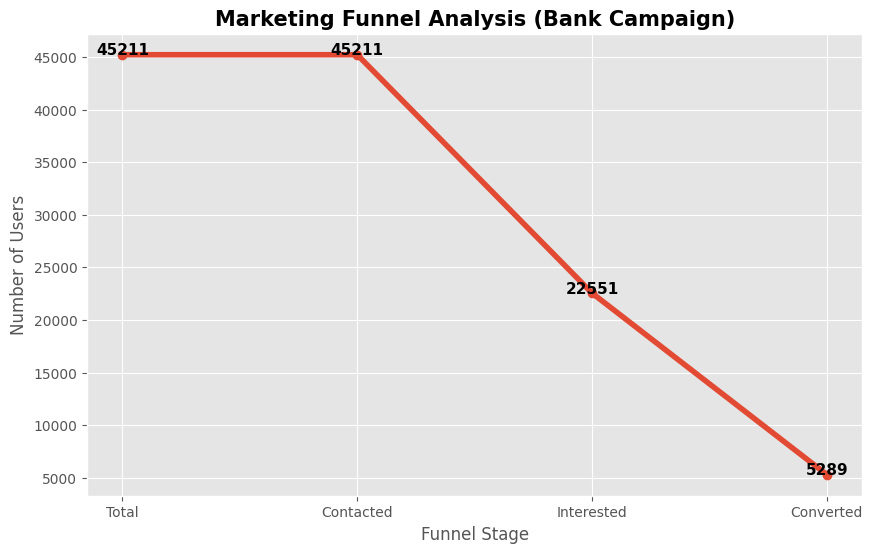

In [38]:
plt.figure(figsize=(10,6))
stages = funnel['Stage']
values = funnel['Users']
plt.plot(stages, values, marker='o', linewidth=4)
for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center', fontsize=11, fontweight='bold')
plt.title("Marketing Funnel Analysis (Bank Campaign)", fontsize=15, fontweight='bold')
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")
plt.show()

In [39]:
funnel['Drop'] = funnel['Users'].diff()
funnel

,Stage,Users,Drop
0,Total,45211,NaN
1,Contacted,45211,0.0
2,Interested,22551,-22660.0
3,Converted,5289,-17262.0


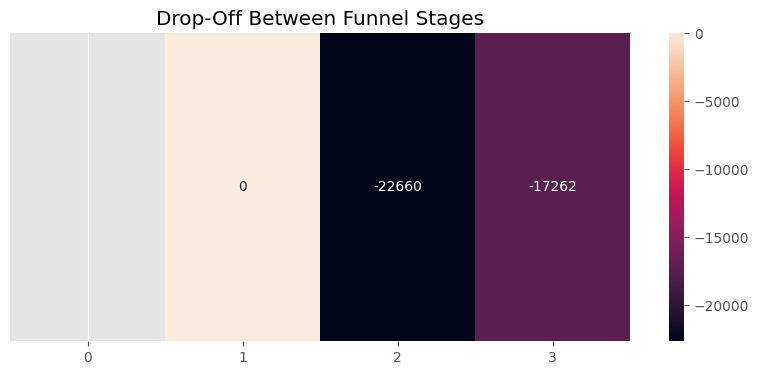

In [40]:
plt.figure(figsize=(10,4))
sns.heatmap([funnel['Drop']], annot=True, fmt='.0f')
plt.title("Drop-Off Between Funnel Stages")
plt.yticks([])
plt.show()

In [41]:
channel = df.groupby('contact').agg(
    total=('y', 'count'),
    conversions=('is_converted', 'sum')
)
channel['conversion_rate'] = channel['conversions'] / channel['total']
channel

,total,conversions,conversion_rate
contact,,,
cellular,29285,4369,0.149189
telephone,2906,390,0.134205
unknown,13020,530,0.040707


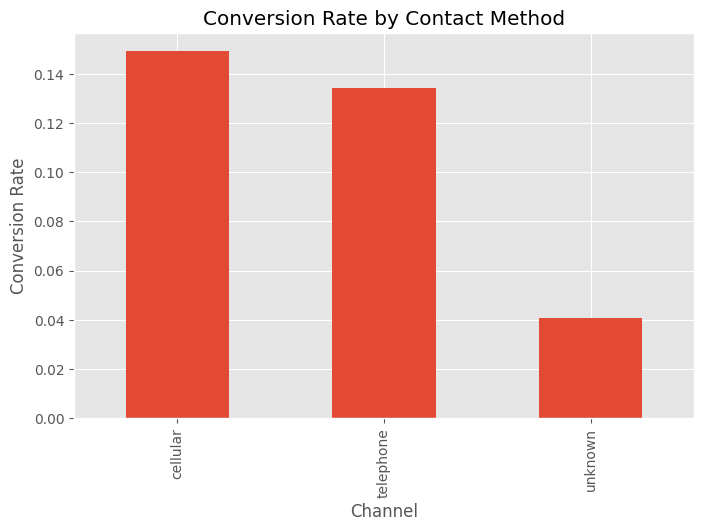

In [42]:
channel['conversion_rate'].plot(kind='bar', figsize=(8,5))
plt.title("Conversion Rate by Contact Method")
plt.xlabel("Channel")
plt.ylabel("Conversion Rate")
plt.show()

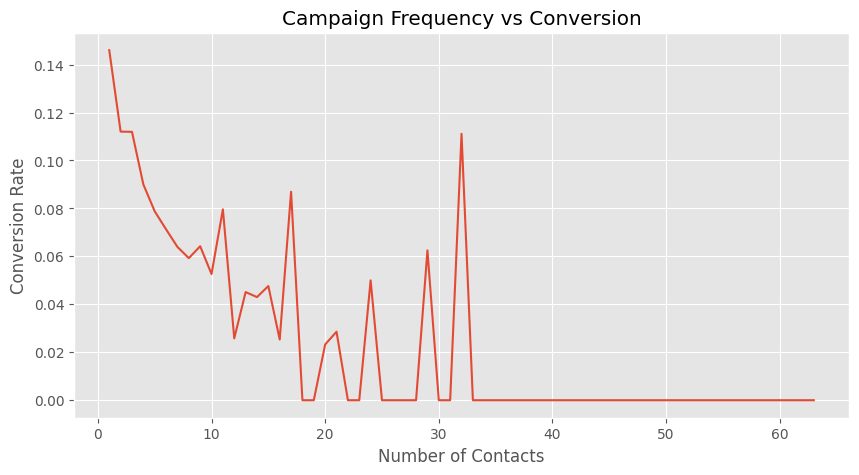

In [43]:
campaign = df.groupby('campaign')['is_converted'].mean()
plt.figure(figsize=(10,5))
campaign.plot()
plt.title("Campaign Frequency vs Conversion")
plt.xlabel("Number of Contacts")
plt.ylabel("Conversion Rate")
plt.show()

In [44]:
segment = df.groupby('job')['is_converted'].mean().sort_values(ascending=False)
segment.head(10)

job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
Name: is_converted, dtype: float64